<h1 style='color: RGB(27, 169, 127); font-size: 50pt';>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen 'Papulator' auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [242]:
versuchsnummer = '241'
versuchsname = 'RLC-Glieder' # Auf Leerzeichen verzichten
aufgabe = '0z'
plt_save_folder = f'../img/plots/'

# Import aller genutzen Libaries

In [243]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

In [244]:
import re
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'c' is your color module and 'plt_save_folder'/'aufgabe' are defined globally
# If not, you can remove the 'safe' saving block or define them locally.

def plot_channels(file_path: str, title: str = None, safe: str = None):
    """
    Plots two channels from a file, centering them correctly around 0V 
    and scaling them to fit the 13x8 oscilloscope grid.
    """
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    # --- 1. Parse Metadata ---
    time_step = 1.0
    time_unit = "s"
    ch_scales = {'CH1': (1.0, 1.0), 'CH2': (1.0, 1.0)} # Default fallback

    for line in lines:
        # Parse Time Step: e.g., "1 = 0.001 s"
        time_match = re.search(r'^(\d+)\s*=\s*([\d.]+)\s*(\w+)', line.strip())
        if time_match:
            _, scale, unit = time_match.groups()
            time_step = float(scale)
            time_unit = unit
        
        # Parse Channel Scale: e.g., "CH1: 10 = 0.5 V"
        ch_match = re.search(r'(CH\d):\s*(\d+)\s*=\s*([\d.]+)\s*V', line.strip())
        if ch_match:
            ch, counts_per_div, volts_per_div = ch_match.groups()
            ch_scales[ch] = (float(counts_per_div), float(volts_per_div))

    # --- 2. Load and Convert Data ---
    # Skip header lines (assumed to be 10 lines based on original code)
    data_lines = lines[10:]
    if not data_lines:
        print("Error: No data lines found after header.")
        return

    try:
        data = np.loadtxt(data_lines)
    except ValueError:
        print("Error: Could not parse numeric data. Check file format.")
        return

    if data.shape[1] < 3:
        print("Error: Data must have at least 3 columns (Time, CH1, CH2).")
        return

    time_idx = data[:, 0]
    ch1_raw = data[:, 1]
    ch2_raw = data[:, 2]

    # Convert raw counts to Volts
    def to_volts(raw_data, scale_tuple):
        counts_per_div, volts_per_div = scale_tuple
        return (raw_data / counts_per_div) * volts_per_div

    ch1_volts = to_volts(ch1_raw, ch_scales['CH1'])
    ch2_volts = to_volts(ch2_raw, ch_scales['CH2'])
    time_sec = time_idx * time_step

    # --- 3. Calculate Auto-Scaling for Grid Fit ---
    # Find the absolute maximum voltage across BOTH channels
    max_voltage = max(np.max(np.abs(ch1_volts)), np.max(np.abs(ch2_volts)))
    
    # Oscilloscope Grid Constants
    y_divs = 8
    x_divs = 13
    
    # We need enough vertical space to fit the max signal with some margin (e.g., 10%)
    # So we calculate the required Volts/Div to fit the signal in 8 divisions
    # Formula: Required_Vdiv = Max_Voltage / (Divisions * Margin_Factor)
    margin_factor = 0.9 # Leave 10% headroom
    required_vdiv = max_voltage / (y_divs * margin_factor)
    
    # Round V/div to a "nice" number (1, 2, 5 sequence) for realistic scope look
    # This step is optional but makes the grid look authentic
    def round_to_125(val):
        if val == 0: return 0.1
        order = np.floor(np.log10(val))
        base = val / (10**order)
        if base <= 1.2: return 1.0 * 10**order
        elif base <= 2.5: return 2.0 * 10**order
        elif base <= 5.0: return 5.0 * 10**order
        else: return 10.0 * 10**order

    final_vdiv = round_to_125(required_vdiv)
    
    # Calculate Y-Limits (Symmetric around 0)
    y_limit = (final_vdiv * y_divs) / 2.0
    
    # Calculate X-Limits (Time)
    x_min, x_max = time_sec.min(), time_sec.max()
    x_range = x_max - x_min
    
    # --- 4. Plotting ---
    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    # Plot Signals
    ax.plot(time_sec, ch1_volts, label=f"CH1 ({ch_scales['CH1'][1]} V/div)", linewidth=1.5)
    ax.plot(time_sec, ch2_volts, label=f"CH2 ({ch_scales['CH2'][1]} V/div)", linewidth=1.5)

    # Set Limits (Centered at 0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-y_limit, y_limit)

    # Generate Grid Ticks
    # Y-ticks: Every 'final_vdiv' step
    y_ticks = np.arange(-y_limit, y_limit + final_vdiv/2, final_vdiv)
    # Ensure 0 is always included
    if 0 not in y_ticks:
        y_ticks = np.insert(y_ticks, len(y_ticks)//2, 0)
    ax.set_yticks(y_ticks)

    # X-ticks: Evenly spaced across 13 divisions
    x_ticks = np.linspace(x_min, x_max, x_divs + 1)
    ax.set_xticks(x_ticks)

    # Styling
    ax.set_title(title if title else "Oscilloscope View")
    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("Voltage [V]")
    
    # Hide tick labels for "Scope" look
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Draw the Ground Line (Mittellinie) at exactly 0V
    ax.axhline(0, color='red', linewidth=1.2, linestyle='-', label='Ground (0V)')
    
    # Optional: Add a faint grid for visual reference
    ax.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

    ax.legend(loc='upper right')

    # Save or Show
    if safe:
        # Ensure variables exist or use defaults
        folder = globals().get('plt_save_folder', './')
        task = globals().get('aufgabe', 'task')
        filename = f"{folder}{safe}_{task}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved to {filename}")
    else:
        plt.show()

    plt.close()

In [245]:
# Definition der Ungenauigkeiten

V_step_err = 3
t_step_err = 5

def calc_step_err(voltage_div, time_div):
    voltage_step = voltage_div / 32
    time_Step = time_div / 50

    return voltage_step * V_step_err, time_Step * t_step_err

# Bauteile -> Prozentuale Fehler!
err_R_p = 0.05
err_C_p = 0.10

<hr>

## Aufgabe 1

In [246]:
# aufgabe = '1a'

# plot_channels('./A1/M1.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 470$nF, $R = 1.0\mathrm{k}\Omega$', safe='M1')

# plot_channels('./A1/M2.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 4.7$nF, $R = 10\mathrm{k}\Omega$', safe='M2')

# plot_channels('./A1/M3.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 47$nF, $R = 1.0\mathrm{k}\Omega$', safe='M3')

# plot_channels('./A1/M4.txt', r'Bestimmung der Halbwertszeit des Stromes mit $C = 47$nF, $R = 1.0\mathrm{k}\Omega$', safe='M4')

In [247]:
# M1: 0.1 V/div, 50 us/div
v_s_err, t_s_err = calc_step_err(0.1, 50)
M1_res = pap.round_sig_digs(t_s_err, 376)

print(f'Für M1 ergibt sich eine Halbwertszeit von: {M1_res[2]} us')

# M2: 0.1 V/div, 5 us/div
v_s_err, t_s_err = calc_step_err(0.1, 5)
M2_res = pap.round_sig_digs(t_s_err, 31.2)

print(f'Für M2 ergibt sich eine Halbwertszeit von: {M2_res[2]} us')

# M3: 0.1 V/div, 5 us/div
v_s_err, t_s_err = calc_step_err(0.1, 5)
M3_res = pap.round_sig_digs(t_s_err, 39.7)

print(f'Für M3 ergibt sich eine Halbwertszeit von: {M3_res[2]} us')

# M4: 0.1 V/div, 20 us/div
v_s_err, t_s_err = calc_step_err(0.1, 20)
M4_res = pap.round_sig_digs(t_s_err, 30.2)

print(f'Für M4 ergibt sich eine Halbwertszeit von: {M4_res[2]} us')

Für M1 ergibt sich eine Halbwertszeit von: 376 \pm 5 us
Für M2 ergibt sich eine Halbwertszeit von: 31.2 \pm 0.5 us
Für M3 ergibt sich eine Halbwertszeit von: 39.7 \pm 0.5 us
Für M4 ergibt sich eine Halbwertszeit von: 30.2 \pm 2.0 us


In [248]:
# Zeitkonstante experimentell
T_half = sp.symbols(r'T_{1/2}')

tau = T_half/sp.ln(2)

values = np.array([
    [M1_res[0], M1_res[1]],
    [M2_res[0] , M2_res[1]], 
    [M3_res[0], M3_res[1]],
    [M4_res[0], M4_res[1]]
])


temp_res = pap.do_it(tau, [T_half], values, [], print_formula=False)

res_in_pm = []
for i, n in enumerate(temp_res):
    str = pap.round_sig_digs(temp_res[i][1], temp_res[i][0])
    res_in_pm.append(str[2])

print(res_in_pm)

['542 \\pm 7', '45.0 \\pm 0.7', '57.3 \\pm 0.7', '44 \\pm 3']


In [249]:
# Bauteile
R_vals = np.array([470.0, 4.7, 47.0, 47.0])
R_err = R_vals * err_R_p

C_vals = np.array([1,10,1,1])
C_err = C_vals * err_C_p

R_Bauteil = []
C_Bauteil = []
for i in range(len(R_vals)):
    temp = pap.round_sig_digs(R_err[i], R_vals[i])
    R_Bauteil.append(temp[2])
    temp = pap.round_sig_digs(C_err[i], C_vals[i])
    C_Bauteil.append(temp[2])


print(R_Bauteil)
print(C_Bauteil)


['470 \\pm 24', '4.70 \\pm 0.24', '47.0 \\pm 2.4', '47.0 \\pm 2.4']
['1.00 \\pm 0.10', '10.0 \\pm 1.0', '1.00 \\pm 0.10', '1.00 \\pm 0.10']


In [250]:
# Zeitkonstante theoretisch
tau_2 = sym.R * sym.C

n=0
values = []
while n < len(R_vals):
    values.append(
        [R_vals[n], R_err[n],
        C_vals[n], C_err[n]]
    )
    n = n + 1

# values = np.array([
#     R_vals[n], R_err[n],
#     C_vals[n], C_err[n]
# ])

temp_res_1 = pap.do_it(tau_2, [sym.R, sym.C], values, [], print_formula=False)

res_in_pm_1 = []
for i, n in enumerate(temp_res_1):
    str = pap.round_sig_digs(temp_res_1[i][1], temp_res_1[i][0])
    res_in_pm_1.append(str[2])

abw_list = []
for i in range(4):
    abw = pap.std_abw(temp_res[i][0], temp_res_1[i][0], temp_res[i][1], temp_res_1[i][1])
    abw_list.append(abw)

print(abw_list)

[np.float64(1.37), np.float64(0.37), np.float64(1.94), np.float64(0.57)]


<hr>

## Aufgabe 2

<hr>

## Aufgabe 3

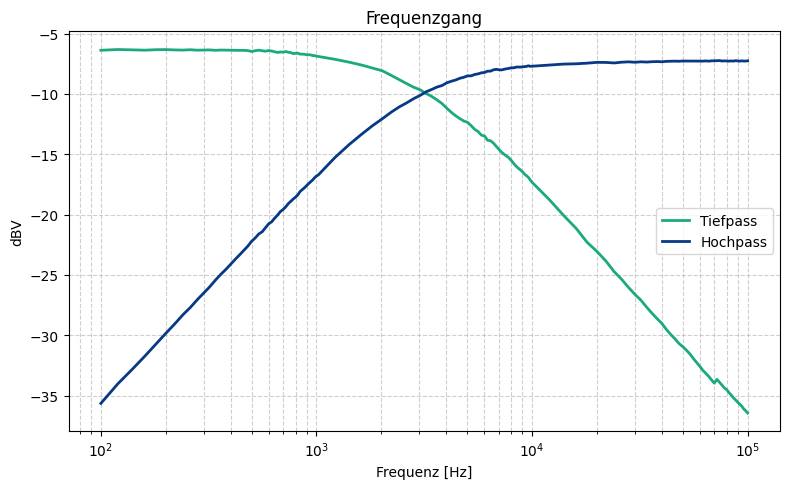

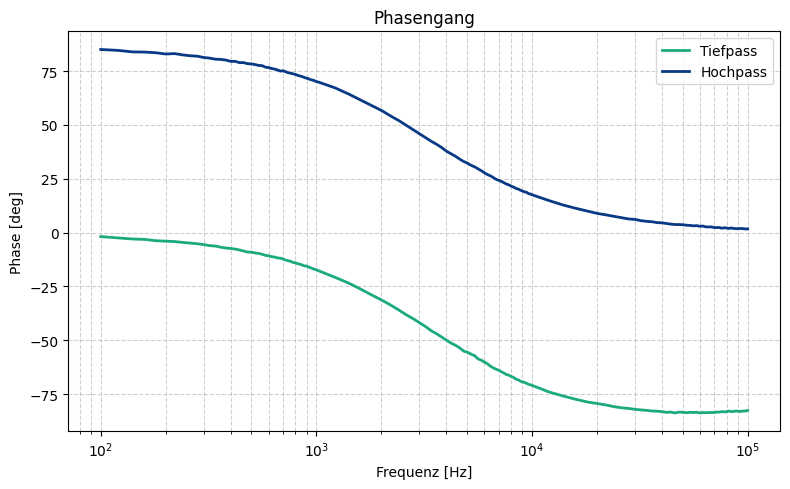

In [251]:
aufgabe = '3a'
filename = "A3/Amplitudenplot_Hochpass.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("Hz"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

# Custom labels and colors
labels = ["Tiefpass", "Hochpass"]
colors = [c.LIGHT_GREEN, c.BLUE]

# Amplituden plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["dBV"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("dBV")
plt.title("Frequenzgang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Frequenzgang_{aufgabe}.pdf')
plt.show()

# Phasen plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["deg"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("Phase [deg]")
plt.title("Phasengang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Phasengang_{aufgabe}.pdf')
plt.show()

In [252]:
# EInheiten in kHz
grenzfreq_tief = 2.72
grenzfreq_hoch = 2.99



err_grenzfreq = calc_step_err(0, 0.25)[1] # Falsche Div Size

err_grenzfreq = 0.25

print(pap.round_sig_digs(err_grenzfreq, grenzfreq_tief)[2])
print(pap.round_sig_digs(err_grenzfreq, grenzfreq_hoch)[2])

abw_exp = pap.std_abw(grenzfreq_hoch ,grenzfreq_tief, err_grenzfreq, err_grenzfreq)

print(fr'Standarabweichung zwischen den Experimentellen Werten: {abw_exp}')


2.7 \pm 0.3
3.0 \pm 0.3
Standarabweichung zwischen den Experimentellen Werten: 0.76


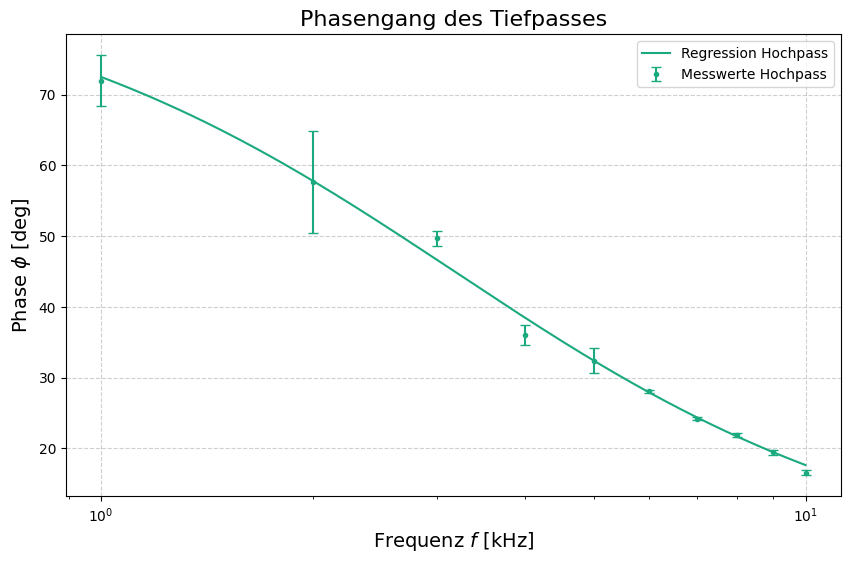

In [253]:
aufgabe = '3b'

freq_gen = np.arange(1,11,1) # 10^3 Hz

hochpass_phasenverschiebung = np.array([200, 80, 46, 25, 18, 13, 9.6, 7.6, 6, 4.6])
err_hochpass_phasenverschiebung = np.array([10, 10, 1, 1, 1, 0.1, 0.1, 0.1, 0.1, 0.1])

phi_hochpass = 360 * freq_gen * hochpass_phasenverschiebung / 1000
err_phi_hochpass = 360 * freq_gen * err_hochpass_phasenverschiebung / 1000

tiefpass_phasenverschiebung = np.array([60, 58.4, 51.6, 42.4, 34.8, 30.8, 28.8, 26.4, 22.8, 20])
err_tiefpass_phasenverschiebung = np.array([10, 10, 1, 1, 1, 0.1, 0.1, 0.1, 0.1, 0.1])

phi_tiefpass = 360 * freq_gen * tiefpass_phasenverschiebung / 1000
err_phi_tiefpass = 360 * freq_gen * err_tiefpass_phasenverschiebung / 1000

# Fit
def arctan(f, f_g):
    return np.arctan(f_g / f) * (360 / (2 * np.pi)) # f_g ist Grenzfrequenz


x_fit = np.arange(1,10,0.01)


# Plot
plt.figure(figsize = (10, 6))
# plt.errorbar(freq_gen, phi_tiefpass, yerr = err_phi_tiefpass, fmt = '.', capsize = 3.5, label = 'Messwerte Tiefpass')
plt.errorbar(freq_gen, phi_hochpass, yerr = err_phi_hochpass, fmt = '.', capsize = 3.5, label = 'Messwerte Hochpass')


# popt, pcov = curve_fit(arctan, freq_gen, phi_tiefpass, sigma = err_phi_tiefpass)
# plt.plot(x_fit, arctan(x_fit, *popt), label = 'Regression Tiefpass')

popt, pcov = curve_fit(arctan, freq_gen, phi_hochpass, sigma = err_phi_hochpass)
plt.plot(x_fit, arctan(x_fit, *popt), label = 'Regression Hochpass', color=c.LIGHT_GREEN)

plt.title('Phasengang des Tiefpasses', size = 16)
plt.xlabel(fr'Frequenz $f$ [kHz]', size = 14)
plt.ylabel(fr'Phase $\phi$ [deg]', size = 14)
plt.xscale('log')
plt.legend(loc ='best')
plt.savefig(fr'{plt_save_folder}Phasengnag_{aufgabe}.pdf')
plt.show()

<hr>

## Aufgabe 4

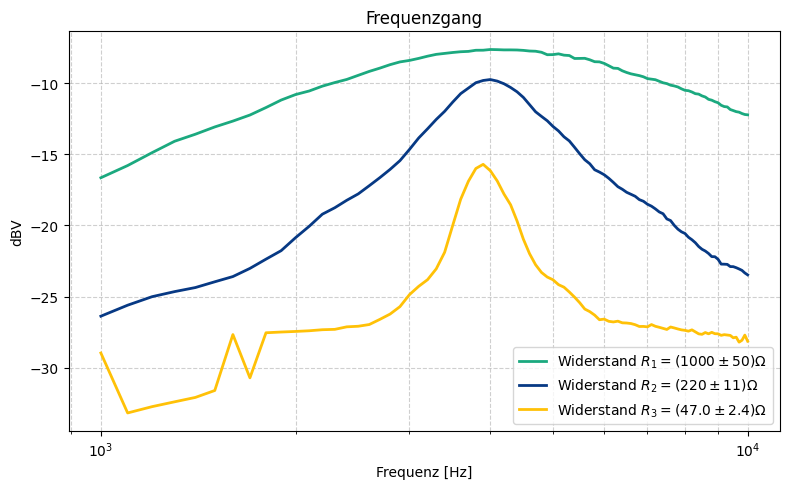

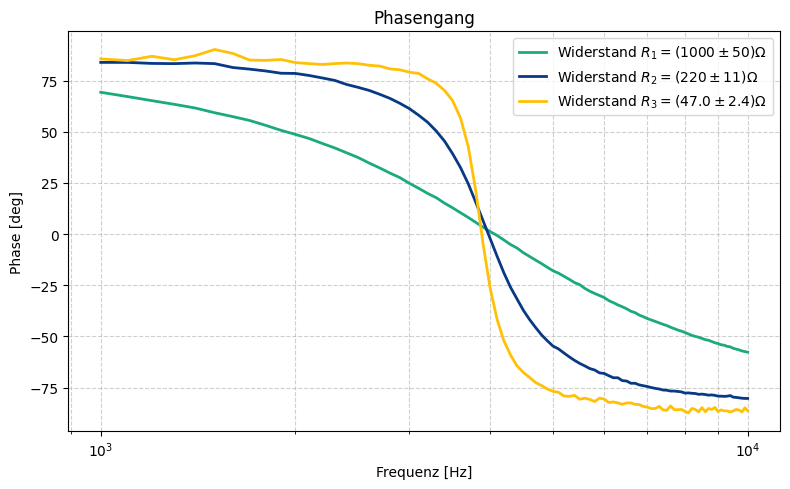

In [254]:
aufgabe = '4a'
filename = "A4/Amplitudenplot_Alle.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("Hz"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

# Custom labels and colors
labels = [fr"Widerstand $R_1 = (1000 \pm 50) \Omega$", fr"Widerstand $R_2 = (220 \pm 11) \Omega$", fr"Widerstand $R_3 = (47.0 \pm 2.4) \Omega$"]
colors = [c.LIGHT_GREEN, c.BLUE, c.YELLOW]

# Amplituden plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["dBV"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("dBV")
plt.title("Frequenzgang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Frequenzgang_{aufgabe}.pdf')
plt.show()

# Phasen plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["deg"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("Phase [deg]")
plt.title("Phasengang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Phasengang_{aufgabe}.pdf')
plt.show()

In [255]:
def dB_to_Voltage(voltage):
    return 10 ** (voltage / 20)

In [256]:
def find_maxima(dfs, labels):
    print(f"{'Dataset':<40} | {'Frequency (Hz)':<15} | {'Max Amplitude (dBV)':<20} | {'Max Amplitude (V)':<20}")
    print("-" * 100)
    amplitude_list = []
    freq_list = []
    for i, df in enumerate(dfs):
        df_sorted = df.sort_values(by="Hz")
        
        # Find peaks in the dBV column
        peaks, _ = find_peaks(df_sorted["dBV"], distance=10, prominence=4)

        if len(peaks) == 0:
            # print(f"{labels[i]:<40} | No peaks found")
            continue
            
        for peak_idx in peaks:
            freq = df_sorted.iloc[peak_idx]["Hz"]
            amp = df_sorted.iloc[peak_idx]["dBV"]
            amplitude_list.append(amp)
            freq_list.append(freq)
            print(f"{labels[i]:<40} | {freq:<15.2f} | {amp:<20.2f} | {dB_to_Voltage(amp):<20.2f}")
        
    return amplitude_list, freq_list

In [257]:
amps, freq = find_maxima(dfs, labels)
amps = np.array([amps])

Spannungen_Ausgang = dB_to_Voltage(amps)

# print(fr'Die Ausgangsspannungen betragen: {np.round(Spannungen_Ausgang, 2)} Volt')

Dataset                                  | Frequency (Hz)  | Max Amplitude (dBV)  | Max Amplitude (V)   
----------------------------------------------------------------------------------------------------
Widerstand $R_1 = (1000 \pm 50) \Omega$  | 4000.00         | -7.64                | 0.42                
Widerstand $R_2 = (220 \pm 11) \Omega$   | 4000.00         | -9.75                | 0.33                
Widerstand $R_3 = (47.0 \pm 2.4) \Omega$ | 3900.00         | -15.71               | 0.16                


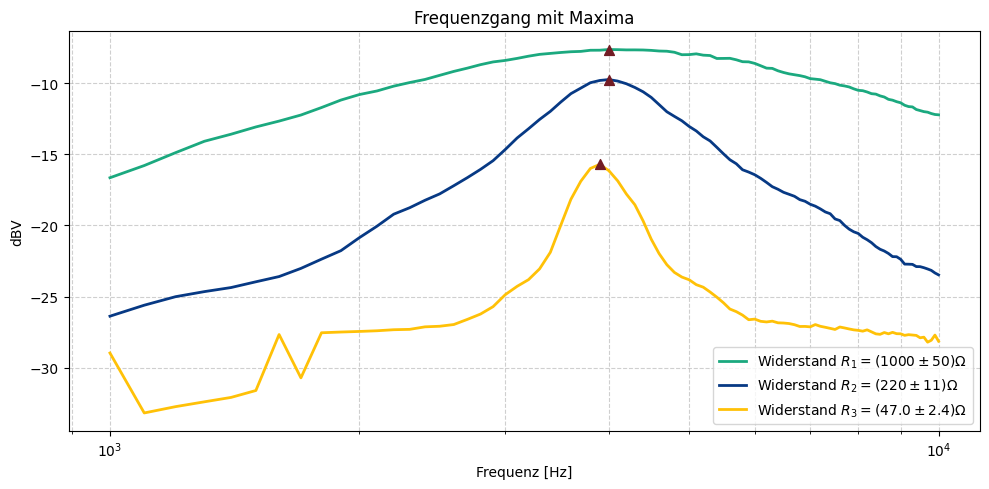

In [258]:
aufgabe = '4b'
filename = "A4/Amplitudenplot_Alle.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("Hz"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

# Custom labels and colors
labels = [fr"Widerstand $R_1 = (1000 \pm 50) \Omega$", fr"Widerstand $R_2 = (220 \pm 11) \Omega$", fr"Widerstand $R_3 = (47.0 \pm 2.4) \Omega$"]
colors = [c.LIGHT_GREEN, c.BLUE, c.YELLOW]

plt.figure(figsize=(10, 5))
for i, df in enumerate(dfs):
    df_sorted = df.sort_values(by="Hz")
    peaks, _ = find_peaks(df_sorted["dBV"], distance=5, prominence=4)
    
    plt.semilogx(df_sorted["Hz"], df_sorted["dBV"], label=labels[i], color=colors[i], linewidth=2)
    
    # Plot markers for peaks
    if len(peaks) > 0:
        plt.scatter(df_sorted.iloc[peaks]["Hz"], 
                    df_sorted.iloc[peaks]["dBV"], 
                    color=c.WINE_RED, s=50, zorder=5, marker='^',)


plt.xlabel("Frequenz [Hz]")
plt.ylabel("dBV")
plt.title("Frequenzgang mit Maxima")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Frequenzgang_{aufgabe}_mit_Maxima.pdf')
plt.show()

In [259]:
# Import der Messwerte
Kapa = 47
Kapa_array = np.array([47, 47, 47]) * 1e-9 #nF ->F
err_Kapa_array = Kapa_array * err_C_p
widerstand = np.array([1, 0.22, 0.047]) * 1000 # kOhm -> Ohm

# linke Bandbreite in kHz
linksBB = np.array([2.01, 3.28, 3.56]) 

# Rechte Bandbreite in kHz
rechtsBB = np.array([8.43, 4.88, 4.31]) 

# Frequenz für das Maximum in kHz
maxFreq = np.array([4.15, 4.06, 3.91])
err_maxFreq  = np.array([0.10, 0.10, 0.10]) 

deltaFreq1 = np.abs(maxFreq - linksBB)
deltaFreq2 = np.abs(maxFreq - rechtsBB)

BB = np.abs(deltaFreq1 + deltaFreq2)/2
err_BB = BB * 0.05

induk = 1/((2 * sp.pi * sym.f)**2 * sym.C)

params = [sym.f, sym.C]

values = np.column_stack([
    maxFreq* 1e3, maxFreq * 0.05e3,
    Kapa_array, err_Kapa_array,
])

temp_induk = pap.do_it(induk, params, values, [], print_formula=False)
print(temp_induk)

[[0.03129293 0.00442549]
 [0.03269568 0.00462387]
 [0.03525242 0.00498544]]


In [260]:
# Erstellen der Latex Tabelle via Pandas

# Strings erstellen
induk_L_1 = []
widerstand_str = []
ResoFreq_str = []
BB_str = []
for i in range(len(widerstand)):
    widerstand_str.append(pap.round_sig_digs(widerstand[i] * err_R_p, widerstand[i])[2])
    ResoFreq_str.append(pap.round_sig_digs(err_maxFreq[i], maxFreq[i])[2])
    BB_str.append(pap.round_sig_digs(err_BB[i], BB[i])[2])
    induk_L_1.append(pap.round_sig_digs(temp_induk[i][1] * 10**2, temp_induk[i][0] * 10**2)[2])

df = pd.DataFrame({
    fr'\text{{Widerstand}} [\Ohm]': widerstand_str,
    fr'\text{{Resonanzfrequenz}} [kHz]': ResoFreq_str,
    fr'\text{{Bandbreite}} [kHz]': BB_str,
    fr'\text{{Induktivität}} L_1 [H]': induk_L_1
})

# Generate LaTeX table
latex_table = df.to_latex(
    index=False,
    caption=fr'Messwerte und berechnete Induktivität mit einer Induktivität von ({Kapa} $\pm$ {Kapa * err_C_p}) nF',
    label='tab:messwerte',
    column_format='C|C|C|C',  
    escape=False 
)

print(latex_table)

\begin{table}
\caption{Messwerte und berechnete Induktivität mit einer Induktivität von (47 $\pm$ 4.7) nF}
\label{tab:messwerte}
\begin{tabular}{C|C|C|C}
\toprule
\text{Widerstand} [\Ohm] & \text{Resonanzfrequenz} [kHz] & \text{Bandbreite} [kHz] & \text{Induktivität} L_1 [H] \\
\midrule
1000 \pm 50 & 4.15 \pm 0.10 & 3.21 \pm 0.16 & 3.1 \pm 0.4 \\
220 \pm 11 & 4.06 \pm 0.10 & 0.80 \pm 0.04 & 3.3 \pm 0.5 \\
47.0 \pm 2.4 & 3.91 \pm 0.10 & 0.375 \pm 0.019 & 3.5 \pm 0.5 \\
\bottomrule
\end{tabular}
\end{table}



In [261]:
# Durchschnittliche Induktivität L_1

asStack = np.column_stack(temp_induk)

avg_induk_L_1 = np.mean(asStack[0])
err_avg_induk_L_1 = np.mean(asStack[1])

res = pap.round_sig_digs(err_avg_induk_L_1* 10**2, avg_induk_L_1 * 10**2)

print(fr'Die durchschneittliche Induktivität liegt bei: ({res[2]}) * 10**-2 H')

Die durchschneittliche Induktivität liegt bei: (3.3 \pm 0.5) * 10**-2 H


### Gesamtwiderstand und Verluste

In [262]:
# Bestimmung des Gesamtwiderstandes
R_ges = 2*sp.pi * sym.f * sym.L

induk_val = []
induk_err = []
for i in range(len(BB)):
    induk_val.append(temp_induk[i][0])
    induk_err.append(temp_induk[i][1])


# BB = deltaFreq2

values = np.column_stack([
    BB, err_BB,
    induk_val, induk_err
])

temp = pap.do_it(R_ges, [sym.f, sym.L], values, [], print_formula=False)
val_R_ges = temp[:,0] * 1000 # Ohm
err_R_ges = temp[:,1] * 1000 # Ohm

print(val_R_ges)

[631.14785807 164.34639933  83.06154914]


In [263]:
# Berechnung des Verlustwidertsandes
R_G_sym = sp.symbols(fr'R_\text{{ges}}') 
R_ver = R_G_sym - sym.R

values = np.column_stack([
    val_R_ges, err_R_ges,
    widerstand, widerstand * err_R_p
])

temp = pap.do_it(R_ver, [R_G_sym, sym.R], values, [], print_formula=False)
val_R_ver = temp[:,0] # Ohm
err_R_ver = temp[:,1] # Ohm

In [264]:
# Berechnung des Verlustwidertsandes über die Spannungen

U_E_sym, U_A_sym = sp.symbols(fr'{{U_\text{{E}}}}, {{U_\text{{A}}}}') 

R_ver_2 = sym.R * ((U_E_sym / U_A_sym) - 1)

params = [sym.R, U_E_sym, U_A_sym]

temp = 0.5
U_eing = np.array([temp, temp, temp])
err_U_eing = U_eing * 0.075

U_ausg = Spannungen_Ausgang[0]
temp = 0.05
err_U_ausg = np.array([temp, temp, temp])


values = np.column_stack([
    widerstand, widerstand * err_R_p,
    U_eing, err_U_eing,
    U_ausg, err_U_ausg
])


# Mit fehlerbehafteten Spannungen
temp = pap.do_it(R_ver_2, params, values, [], print_formula=False)
val_R_ver_2 = temp[:,0]
err_R_ver_2 = temp[:,1]

print('Verlustwiderstan:')
for i in range(3):
    print(pap.round_sig_digs(err_R_ver_2[i], val_R_ver_2[i])[2])

pap.std_abw(val_R_ver_2, val_R_ver, err_R_ver_2, err_R_ver)

Verlustwiderstan:
200 \pm 170
120 \pm 60
100 \pm 50


array([2.84, 2.71, 1.28])

In [265]:
# Ertsellen der Latex_Tabelle

# Strings erstellen
wid_sum = []
wid_ver = []
for i in range(len(widerstand)):
    wid_sum.append(pap.round_sig_digs(err_R_ges[i], val_R_ges[i])[2])
    wid_ver.append(pap.round_sig_digs(err_R_ver[i], val_R_ver[i])[2])

df = pd.DataFrame({
    fr'\text{{Bandbreite}} f_\text{{band}} \ [10^{{3}}\mathrm{{Hz}}]': BB_str,
    fr'\text{{Induktivität}} L_1 \ [10^{{-2}}\mathrm{{H}}]': induk_L_1,
    fr'\text{{Widerstand}} [\mathrm{{\Ohm}}]': widerstand_str,
    fr'R + R_\text{{V}} [\mathrm{{\Ohm}}]': wid_sum,
    fr'R_\text{{V}} [\mathrm{{\Ohm}}]': wid_ver,
})

# Generate LaTeX table
latex_table = df.to_latex(
    index=False,
    caption=fr'Berechnung des Verlustwiderstands durch Bandbreite und Induktivität.',
    label='tab:messwerte_widerstande',
    column_format='C | C | C | C | C',  
    escape=False 
)

print(latex_table)

\begin{table}
\caption{Berechnung des Verlustwiderstands durch Bandbreite und Induktivität.}
\label{tab:messwerte_widerstande}
\begin{tabular}{C | C | C | C | C}
\toprule
\text{Bandbreite} f_\text{band} \ [10^{3}\mathrm{Hz}] & \text{Induktivität} L_1 \ [10^{-2}\mathrm{H}] & \text{Widerstand} [\mathrm{\Ohm}] & R + R_\text{V} [\mathrm{\Ohm}] & R_\text{V} [\mathrm{\Ohm}] \\
\midrule
3.21 \pm 0.16 & 3.1 \pm 0.4 & 1000 \pm 50 & 630 \pm 90 & -370 \pm 110 \\
0.80 \pm 0.04 & 3.3 \pm 0.5 & 220 \pm 11 & 164 \pm 25 & -60 \pm 30 \\
0.375 \pm 0.019 & 3.5 \pm 0.5 & 47.0 \pm 2.4 & 83 \pm 12 & 36 \pm 13 \\
\bottomrule
\end{tabular}
\end{table}



<hr>

## Aufgabe 5

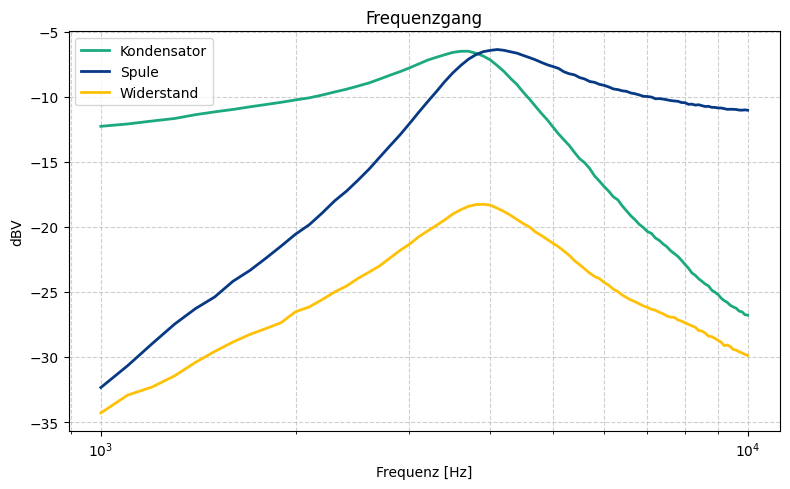

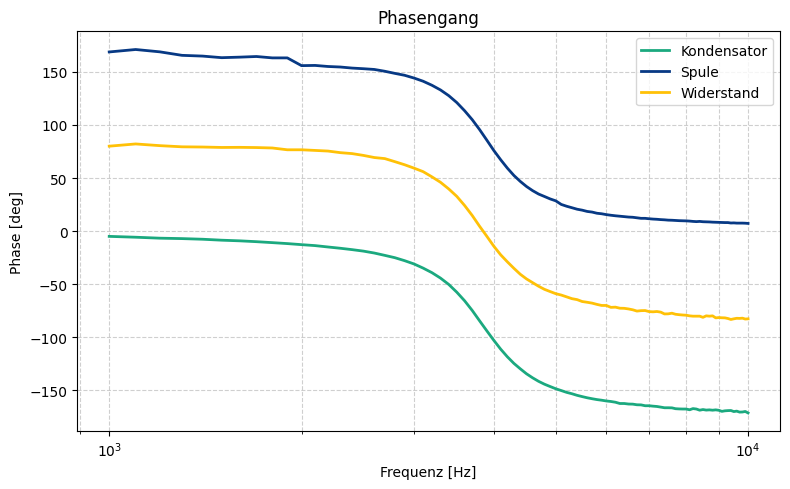

In [266]:
aufgabe = '5a'
filename = "A5/ResonanzkurvenAlleBauteile.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("Hz"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

# Custom labels and colors
labels = [ "Kondensator", "Spule", "Widerstand"]
colors = [c.LIGHT_GREEN, c.BLUE, c.YELLOW]

# Amplituden plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["dBV"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("dBV")
plt.title("Frequenzgang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Frequenzgang_{aufgabe}.pdf')
plt.show()

# Phasen plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["deg"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("Phase [deg]")
plt.title("Phasengang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Phasengang_{aufgabe}.pdf')
plt.show()

In [267]:
# Bestimmung der Induktivitäten je nach Bauteil

resoFreq_R = 3.63
resoFreq_C = 3.91
resoFreq_L = 4.09

array_bauteile_freq = np.array([resoFreq_R, resoFreq_C, resoFreq_L])

Kapa_array = np.array([47, 47, 47]) * 1e-9 #nF ->F
err_Kapa_array = Kapa_array * err_C_p


induk = 1/((2 * sp.pi * sym.f)**2 * sym.C)

params = [sym.f, sym.C]

values = np.column_stack([
    array_bauteile_freq * 1e3, array_bauteile_freq * 0.05e3,
    Kapa_array, err_Kapa_array,
])

temp_induk = pap.do_it(induk, params, values, [], print_formula=False)
val_induk_R = temp_induk[0][0]
err_induk_R = temp_induk[0][1]

val_induk_C = temp_induk[1][0]
err_induk_C = temp_induk[1][1]

val_induk_L = temp_induk[2][0]
err_induk_L = temp_induk[2][1]

print(fr'Induktivität über den Widerstand: {pap.round_sig_digs(err_induk_R, val_induk_R)[2]}')
print(fr'Induktivität über den Kondensator: {pap.round_sig_digs(err_induk_C, val_induk_C)[2]}')
print(fr'Induktivität über die Spule: {pap.round_sig_digs(err_induk_L, val_induk_L)[2]}')

Induktivität über den Widerstand: 0.041 \pm 0.006
Induktivität über den Kondensator: 0.035 \pm 0.005
Induktivität über die Spule: 0.032 \pm 0.005


In [268]:
pap.std_abw(avg_induk_L_1, val_induk_L, err_avg_induk_L_1, err_induk_L)

np.float64(0.13)

<hr>

## Aufgabe 6

In [269]:
voltage = np.array([4.63, 2.84, 1.69, 1.03, 0.69, 0.47, 0.31]) # Amplituden
period_t = np.array([0.26, 0.27, 0.26, 0.26, 0.25, 0.26]) * 1e-3 # ms in s

calc_step_err(1, 0.2)

(0.09375, 0.02)

In [270]:
error_abs = 0.09375

log_decrements = np.log(voltage[:-1] / voltage[1:])

err_n = error_abs / voltage[:-1]
err_np1 = error_abs / voltage[1:]

err_lambda = np.sqrt(err_n**2 + err_np1**2)

avg_log_decrements = np.mean(log_decrements)
err_avg_log_decrements = np.mean(err_lambda)

print(fr'Log Dek avg: {pap.round_sig_digs(err_avg_log_decrements, avg_log_decrements)[2]}')

Log Dek avg: 0.45 \pm 0.16


### Bestimmung Dämpfungskonstante

In [271]:
schwingDau_T = np.mean(period_t)
abs_err_t = 0.02 * 1e-3 # ms in s
err_schwingDau_T = np.sqrt(np.std(period_t)**2 + abs_err_t**2)
print(fr'Die Schwingdauer beträgt ({pap.round_sig_digs(err_schwingDau_T, schwingDau_T)[2]}) s')

DampfKonnst = sym.Lambda / sym.T

values = np.array([
    avg_log_decrements, err_avg_log_decrements,
    schwingDau_T, err_schwingDau_T
])

temp = pap.do_it(DampfKonnst, [sym.Lambda, sym.T], values, [], print_formula=False) 
val_dampf_konst = temp[0][0]
err_dampf_konst = temp[0][1]

print(fr'Die Dämpfungkonstante lautet {pap.round_sig_digs(err_dampf_konst, val_dampf_konst)[2]}')

Die Schwingdauer beträgt (0.000260 \pm 0.000021) s
Die Dämpfungkonstante lautet 1700 \pm 600


### Widerstandsbestimmung

In [272]:
avg_L1 = (avg_induk_L_1 + val_induk_L)/2
err_avg_L1 = np.sqrt(err_induk_L**2 + err_avg_induk_L_1**2)
print(fr'Die Induktivität der Spule L_1 beträgt ({pap.round_sig_digs(err_avg_L1, avg_L1)[2]})')

ges_wid_A6 = 2 * sym.L * sym.delta

values = np.array([
    avg_L1, err_avg_L1,
    val_dampf_konst, err_dampf_konst
])

temp = pap.do_it(ges_wid_A6, [sym.L, sym.delta], values, print_formula=False)
val_ges_wid_A6 = temp[0][0]
err_ges_wid_A6 = temp[0][1]

print(fr'Der Gesamt widerstand beträgt: ({pap.round_sig_digs(err_ges_wid_A6, val_ges_wid_A6)[2]}) Ohm')

Die Induktivität der Spule L_1 beträgt (0.033 \pm 0.007)
Der Gesamt widerstand beträgt: (110 \pm 50) Ohm


In [273]:
# Verlustwiderstand
val_ver_wid_A6 = val_ges_wid_A6 - 47.0
err_ver_wid_A6 = np.sqrt(err_ges_wid_A6**2 + 2.4**2)

print(fr'Der Verlustwiderstand beträgt ({pap.round_sig_digs(err_ver_wid_A6, val_ver_wid_A6)[2]} Ohm)')

Der Verlustwiderstand beträgt (70 \pm 50 Ohm)


In [274]:
#Abweichungen zu vorherigen Ergebnissen
print('VERLUST WIDERSTAND')
print(fr'Abweichung zu den Werten der Bandbreite: {pap.std_abw(val_ver_wid_A6, val_R_ver[2], err_ver_wid_A6, err_R_ver[2])}')
print(fr'Abweichung zu den Werten der Resonanzüberhöhung: {pap.std_abw(val_ver_wid_A6, val_R_ver_2[2], err_ver_wid_A6, err_R_ver_2[2])}')

print('=' * 10)

print('GESAMT WIDERSTAND')

ges_wid_A2 = val_R_ver_2[2] + 47
err_ges_wid_A2 = np.sqrt(err_R_ver_2[2]**2 + 2.4**2)

print(err_ges_wid_A2)

print(fr'Abweichung zu den Werten der Bandbreite: {pap.std_abw(val_ver_wid_A6, val_R_ges[2], err_ver_wid_A6, err_R_ges[2])}')
print(fr'Abweichung zu den Werten der Resonanzüberhöhung: {pap.std_abw(val_ver_wid_A6, ges_wid_A2, err_ver_wid_A6, err_ges_wid_A2)}')


VERLUST WIDERSTAND
Abweichung zu den Werten der Bandbreite: 0.61
Abweichung zu den Werten der Resonanzüberhöhung: 0.46
GESAMT WIDERSTAND
45.32867562307693
Abweichung zu den Werten der Bandbreite: 0.34
Abweichung zu den Werten der Resonanzüberhöhung: 1.17


### Reso Freq

In [275]:
reso_freq_A6 =1 / sym.T

values = np.array([
    schwingDau_T, err_schwingDau_T
])

temp = pap.do_it(reso_freq_A6, [sym.T], values, print_formula=False)
val_reso_freq_A6 = temp[0][0]
err_reso_freq_A6 = temp[0][1] 
print(fr'Reso Freq: {pap.round_sig_digs(err_reso_freq_A6, val_reso_freq_A6)[2]}')

Reso Freq: 3800 \pm 300


In [276]:
print(fr'StdAbw: {pap.std_abw(val_reso_freq_A6, 3910, err_reso_freq_A6, 100)}')

StdAbw: 0.2


<hr>

## Aufgabe 7

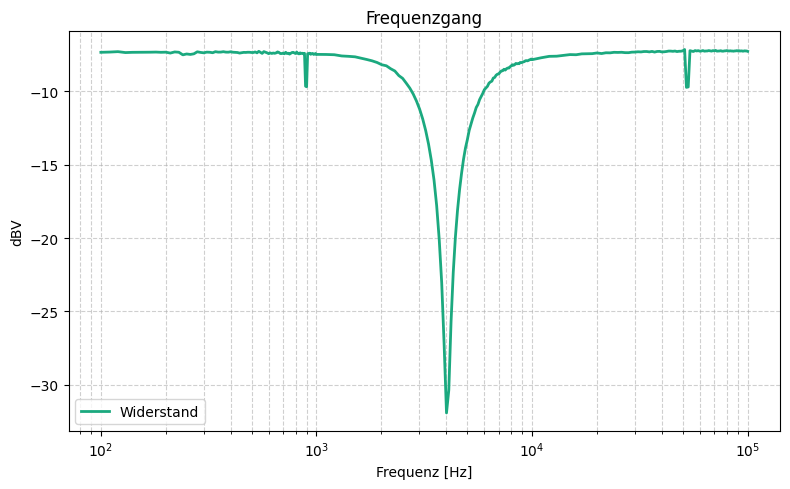

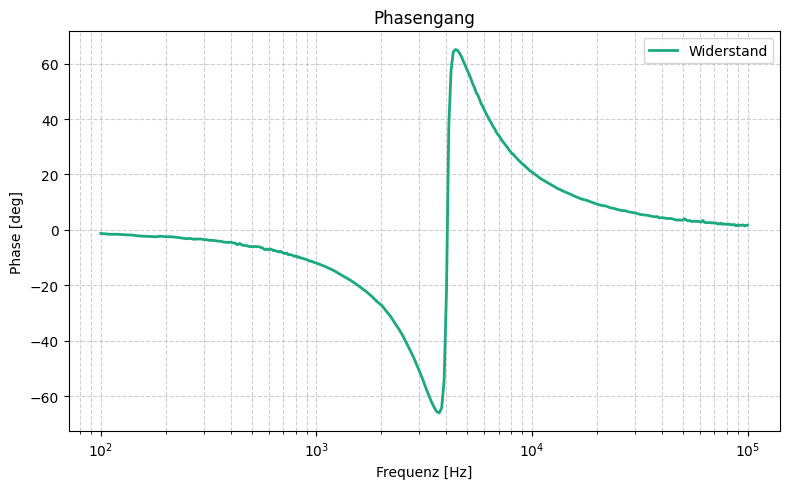

In [277]:
aufgabe = '7a'
filename = "A7/Frequenzgang_mit_Resonanzfrequenz.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("Hz"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

# Custom labels and colors
labels = ["Widerstand"]
colors = [c.LIGHT_GREEN]

# Amplituden plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["dBV"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("dBV")
plt.title("Frequenzgang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Frequenzgang_{aufgabe}.pdf')
plt.show()

# Phasen plot
plt.figure(figsize=(8,5))

for i, df in enumerate(dfs):
    plt.semilogx(
        df["Hz"],
        df["deg"],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

plt.xlabel("Frequenz [Hz]")
plt.ylabel("Phase [deg]")
plt.title("Phasengang")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(fr'{plt_save_folder}Phasengang_{aufgabe}.pdf')
plt.show()

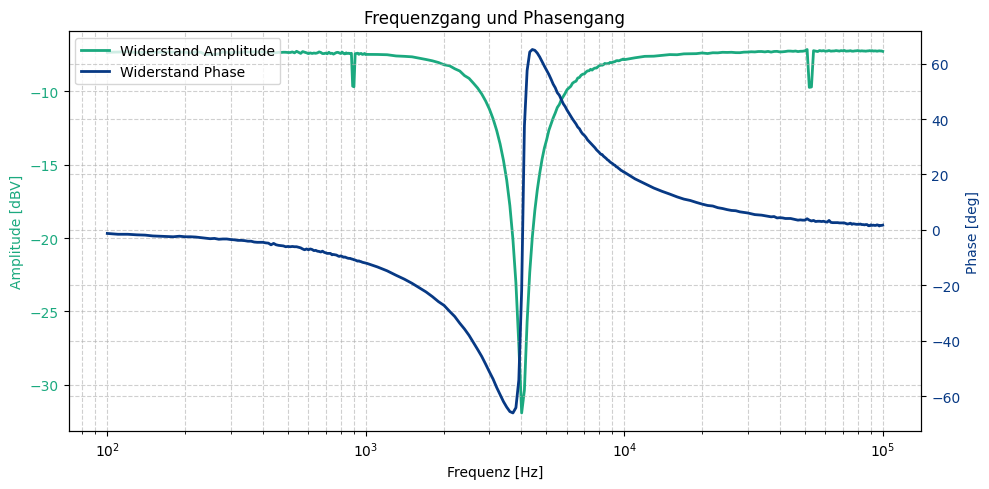

In [278]:
labels = ["Widerstand"]
colors = [c.LIGHT_GREEN] 

fig, ax1 = plt.subplots(figsize=(10, 5))

for i, df in enumerate(dfs):
    ax1.semilogx(
        df["Hz"],
        df["dBV"],
        label=f"{labels[i]} Amplitude",
        color=colors[i],
        linewidth=2
    )

ax1.set_xlabel("Frequenz [Hz]")
ax1.set_ylabel("Amplitude [dBV]", color=colors[0])
ax1.tick_params(axis='y', labelcolor=colors[0])
ax1.grid(True, which="both", linestyle="--", alpha=0.6)

ax2 = ax1.twinx()

for i, df in enumerate(dfs):
    ax2.semilogx(
        df["Hz"],
        df["deg"],
        label=f"{labels[i]} Phase",
        color=c.BLUE,
        linewidth=2,
        # linestyle='--'
    )

ax2.set_ylabel("Phase [deg]", color=c.BLUE)
ax2.tick_params(axis='y', labelcolor=c.BLUE)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title("Frequenzgang und Phasengang")
plt.tight_layout()

plt.savefig(f'{plt_save_folder}Frequenzgang_Phasengang_Kombiniert_{aufgabe}.pdf')
plt.show()

In [279]:
f_teso = 1 / (2 * sp.pi * sp.sqrt(sym.L * sym.C))

values = np.array([
    avg_L1, err_avg_L1, #H
    47 * 1e-9, 2.4 * 1e-9 #nF -> F
])

print(values)

temp = pap.do_it(f_teso, [sym.L, sym.C], values, print_formula=False)
val_f_teso = temp[0][0]
err_f_teso = temp[0][1]
print(fr'Theoretische Resonanzfrequenz: {pap.round_sig_digs(err_f_teso, val_f_teso)[2]}')

[3.26490670e-02 6.53038306e-03 4.70000000e-08 2.40000000e-09]
Theoretische Resonanzfrequenz: 4100 \pm 400


In [280]:
#Standard abweichungen

print(pap.std_abw(val_f_teso, 3800, err_f_teso, 300))

print(pap.std_abw(val_f_teso, 3910, err_f_teso, 100))


0.51
0.35


<hr>

## Aufgabe 8

In [281]:
freq_A8 = np.array([100, 3590, 7990]) #Hz

# Amplituden in dBV
ohne_Filter = np.array([-1.81, -7.44, -7.75])

Hochpass = np.array([-31.19, -10.56, -9.00])

RC_Tiefpass = np.array([-1.81, -11.50, -16.81])
LC_Tiefpass = np.array([-80.59, 9.94, -5.69])

Bandfilter_1K = np.array([-31.00, -7.87, -12.25])
Bandfilter_47 = np.array([-57.25, -17.56, -37.25])

filter = [
    "Ohne Filter",
    "HP",
    "RC TP",
    "LC TP",
    "Bandf. 1k",
    "Bandf. 47"
]

data = {"Frequenz [Hz]": freq_A8}

for i, name in enumerate(filter):
    dbv_vals = [ohne_Filter, Hochpass, RC_Tiefpass, LC_Tiefpass, Bandfilter_1K, Bandfilter_47][i]
    v_vals = dB_to_Voltage(dbv_vals)
    # data[f"{name} (dBV)"] = dbv_vals
    data[f"{name} [V]"] = (v_vals)


df = pd.DataFrame(data)

df_latex = df.round(3)

latex_table = df_latex.to_latex(
    index=False,
    column_format="l" + "r" * (len(filter) * 2),
    caption="Messwerte der Amplituden in dBV und Volt bei verschiedenen Frequenzen",
    label="tab:amplituden_messwerte",
    escape=True
)

print(latex_table)

\begin{table}
\caption{Messwerte der Amplituden in dBV und Volt bei verschiedenen Frequenzen}
\label{tab:amplituden_messwerte}
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
Frequenz [Hz] & Ohne Filter [V] & HP [V] & RC TP [V] & LC TP [V] & Bandf. 1k [V] & Bandf. 47 [V] \\
\midrule
100 & 0.812000 & 0.028000 & 0.812000 & 0.000000 & 0.028000 & 0.001000 \\
3590 & 0.425000 & 0.296000 & 0.266000 & 3.141000 & 0.404000 & 0.132000 \\
7990 & 0.410000 & 0.355000 & 0.144000 & 0.519000 & 0.244000 & 0.014000 \\
\bottomrule
\end{tabular}
\end{table}



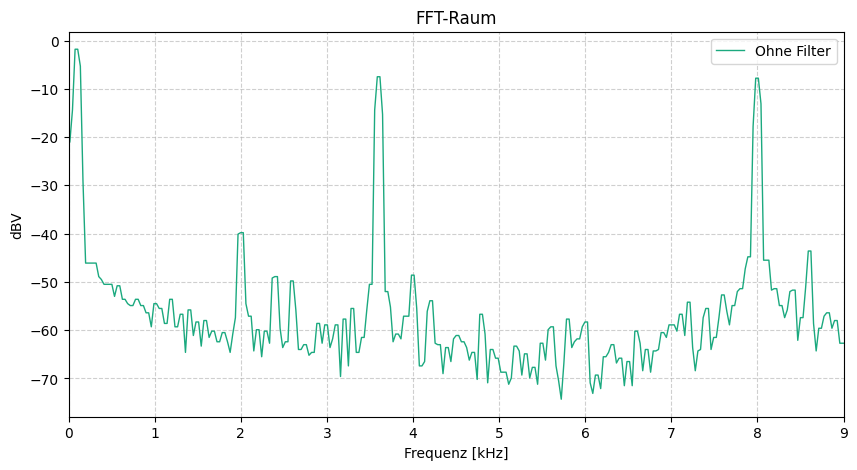

<Axes: title={'center': 'FFT-Raum'}, xlabel='Frequenz [kHz]', ylabel='dBV'>

In [282]:
aufgabe = '8a'
filename = "A8/FFT_Ohne-Filter.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

blocks = []
current_block = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    # Detect new block
    if line.startswith("N"):
        if current_block:
            blocks.append(current_block)
            current_block = []

        current_block.append(line)

    else:
        current_block.append(line)

if current_block:
    blocks.append(current_block)

# Convert to DataFrames
dfs = []

for block in blocks:
    text = "\n".join(block)

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+"
    )

    dfs.append(df)

labels = [filter]

plt.figure(figsize=(10,5))

for i, df in enumerate(dfs):
    plt.plot(
        df["f/[kHz]"],
        df["V/[dBV]"],
        label=filter[i],
        linewidth=1
    )

plt.xlim(0,9)
pap.plot_me("FFT-Raum", "Frequenz [kHz]", "dBV", fr'{plt_save_folder}Frequenzgang_{aufgabe}.pdf')

Bandfilter 47$\Omega$


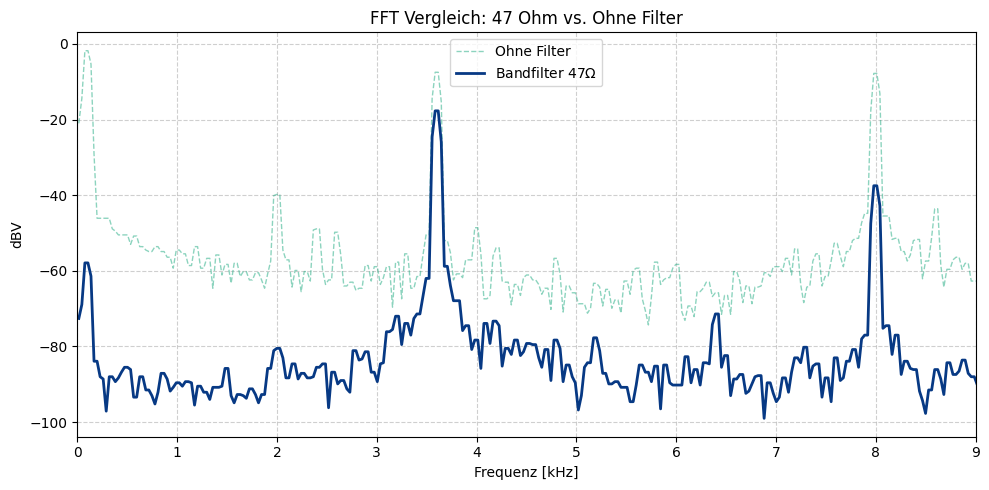

Saved: ../img/plots/FFT_Vergleich_47_Ohm_8b.pdf
Bandfilter 1000$\Omega$


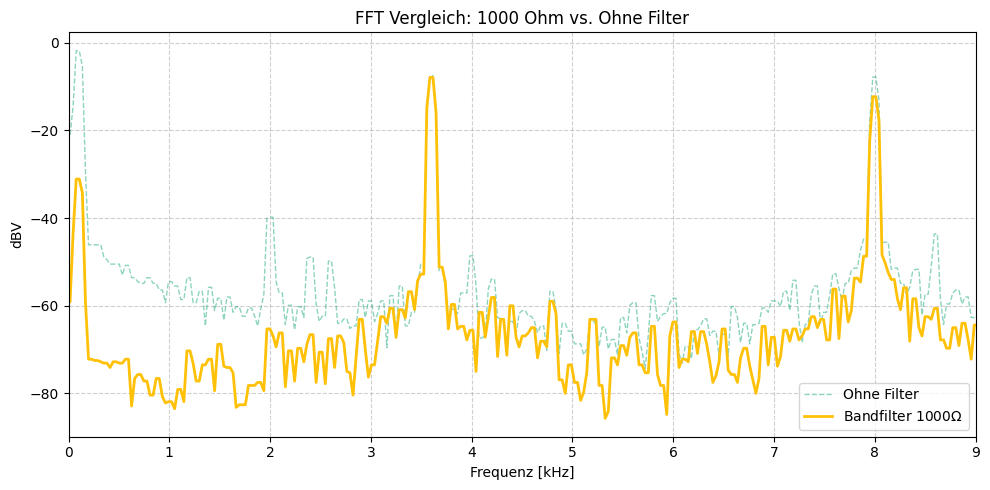

Saved: ../img/plots/FFT_Vergleich_1000_Ohm_8b.pdf


In [283]:
aufgabe = '8b'
files = [    
    'A8/FFT_Ohne-Filter.txt',
    'A8/FFT_Bandpassfilter_47Ohm.txt',
    'a8/FFT_Bandpassfilter_1KOhm.txt'
]

labels = ['Ohne Filter', r'Bandfilter 47$\Omega$', r'Bandfilter 1000$\Omega$']

all_dfs = []

for idx, file in enumerate(files):
    if not os.path.exists(file):
        file = file.replace('a8/', 'A8/')
        
    with open(file, "r") as f:
        lines = f.readlines()

    blocks = []
    current_block = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith("N"):
            if current_block:
                blocks.append(current_block)
                current_block = []
            current_block.append(line)
        else:
            current_block.append(line)
            
    if current_block:
        blocks.append(current_block)

    dfs = []
    for block in blocks:
        text = "\n".join(block)
        df = pd.read_csv(StringIO(text), sep=r"\s+")
        dfs.append(df)
    
    if dfs:
        all_dfs.append(dfs[0])
    else:
        all_dfs.append(None)

ref_df = all_dfs[0]
ref_label = labels[0]

comparisons = [
    (1, labels[1], '47 Ohm'),
    (2, labels[2], '1000 Ohm')
]

for idx, filter_idx, filter_name in comparisons:
    print(filter_idx)
    target_df = all_dfs[idx]
    
    if ref_df is None or target_df is None:
        print(f"Skipping {filter_name}: Missing data.")
        continue

    plt.figure(figsize=(10, 5))

    plt.plot(
        ref_df["f/[kHz]"],
        ref_df["V/[dBV]"],
        label=ref_label,
        color=c.LIGHT_GREEN,
        linewidth=1,
        alpha=0.5,  
        linestyle='--' 
    )

    plt.plot(
        target_df["f/[kHz]"],
        target_df["V/[dBV]"],
        label=labels[idx],
        linewidth=2,
        color=c.BLUE if '47' in filter_name else c.YELLOW
    )

    plt.xlim(0, 9)
    plt.xlabel("Frequenz [kHz]")
    plt.ylabel("dBV")
    plt.title(f"FFT Vergleich: {filter_name} vs. Ohne Filter")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    save_filename = f'{plt_save_folder}FFT_Vergleich_{filter_name.replace(" ", "_")}_{aufgabe}.pdf'
    plt.savefig(save_filename)
    plt.show()
    
    print(f"Saved: {save_filename}")

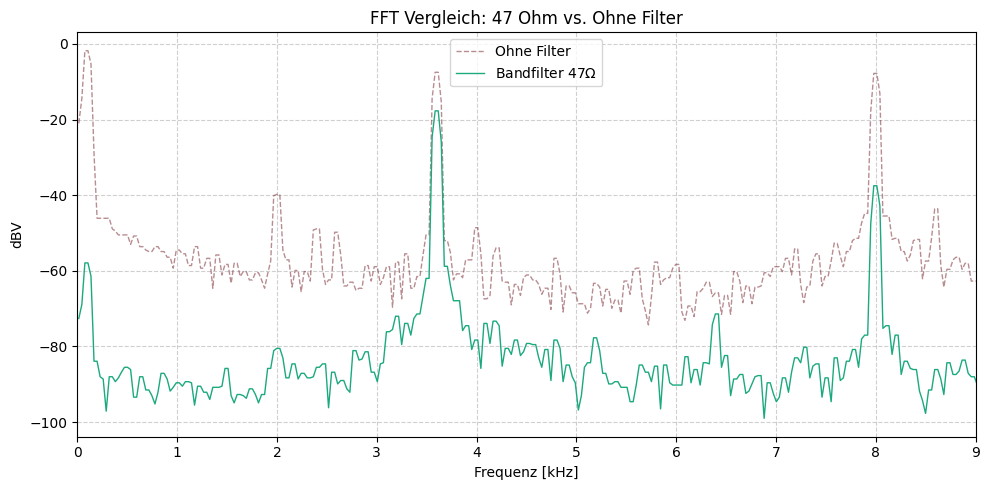

Saved: ../img/plots/FFT_Vergleich_47_Ohm_8c.pdf


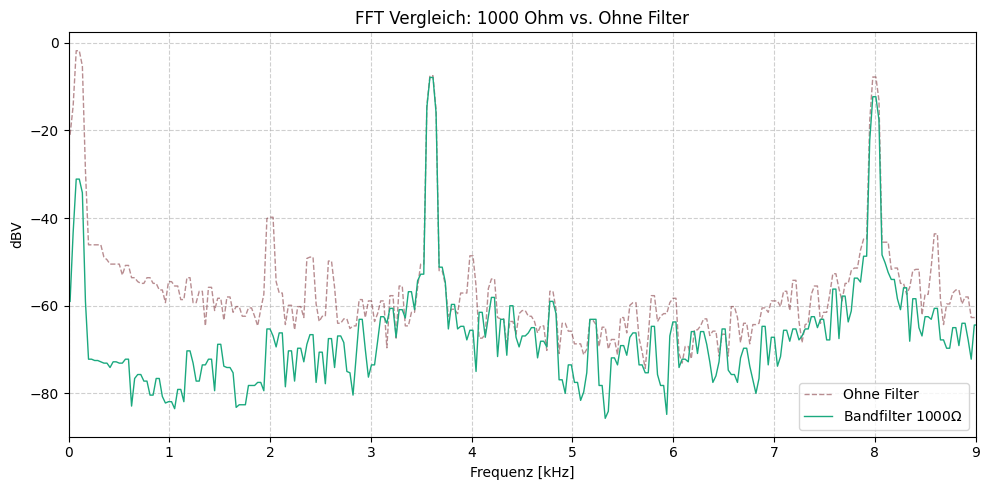

Saved: ../img/plots/FFT_Vergleich_1000_Ohm_8c.pdf


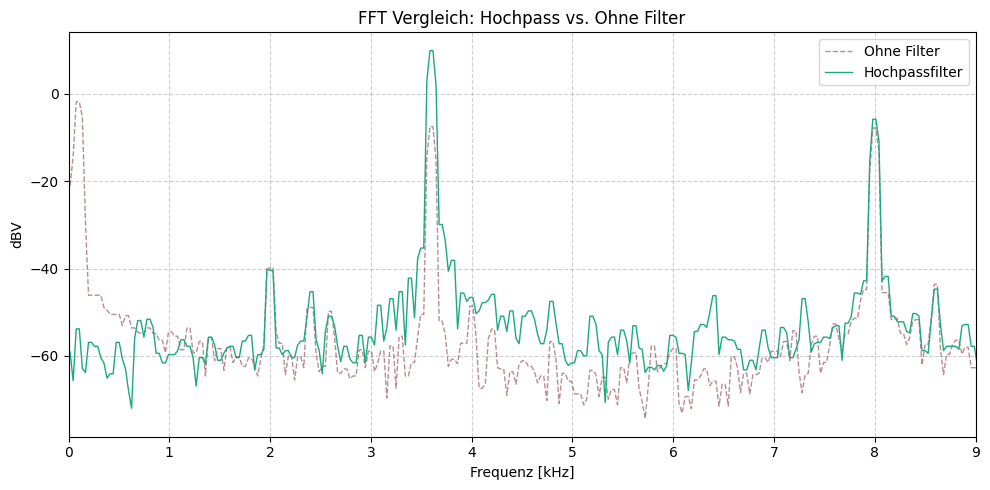

Saved: ../img/plots/FFT_Vergleich_Hochpass_8c.pdf


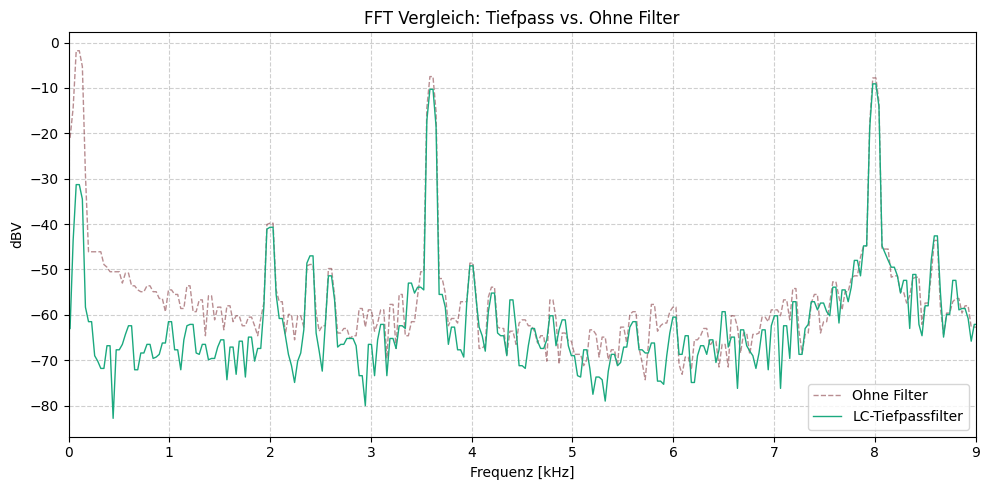

Saved: ../img/plots/FFT_Vergleich_Tiefpass_8c.pdf


In [ ]:
aufgabe = '8c'
files = [    
    'A8/FFT_Ohne-Filter.txt',
    'A8/FFT_Bandpassfilter_47Ohm.txt',
    'A8/FFT_Bandpassfilter_1KOhm.txt',
    'A8/FFT_LC-Tiefpass-Filter.txt',
    'A8/FFT_Hochpass-Filter.txt'
]

labels = [
    'Ohne Filter',
    r'Bandfilter 47$\Omega$', 
    r'Bandfilter 1000$\Omega$',
    r'Hochpassfilter',
    r'LC-Tiefpassfilter',
    ]

all_dfs = []

for idx, file in enumerate(files):
    if not os.path.exists(file):
        raise ValueError('File not found.')
        
    with open(file, "r") as f:
        lines = f.readlines()

    blocks = []
    current_block = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith("N"):
            if current_block:
                blocks.append(current_block)
                current_block = []
            current_block.append(line)
        else:
            current_block.append(line)
            
    if current_block:
        blocks.append(current_block)

    dfs = []
    for block in blocks:
        text = "\n".join(block)
        df = pd.read_csv(StringIO(text), sep=r"\s+")
        dfs.append(df)
    
    if dfs:
        all_dfs.append(dfs[0])
    else:
        all_dfs.append(None)

ref_df = all_dfs[0]
ref_label = labels[0]

comparisons = [
    (1, labels[1], '47 Ohm'),
    (2, labels[2], '1000 Ohm'),
    (3, labels[3], 'Hochpass'),
    (4, labels[4], 'Tiefpass')
]



for idx, filter_idx, filter_name in comparisons:
    target_df = all_dfs[idx]
    
    if ref_df is None or target_df is None:
        print(f"Skipping {filter_name}: Missing data.")
        continue

    plt.figure(figsize=(10, 5))

    plt.plot(
        ref_df["f/[kHz]"],
        ref_df["V/[dBV]"],
        label=ref_label,
        color=c.WINE_RED,
        linewidth=1,
        alpha=0.5,  
        linestyle='--' 
    )

    plt.plot(
        target_df["f/[kHz]"],
        target_df["V/[dBV]"],
        label=labels[idx],
        linewidth=1,
    )

    plt.xlim(0, 9)
    plt.xlabel("Frequenz [kHz]")
    plt.ylabel("dBV")
    plt.title(f"FFT Vergleich: {filter_name} vs. Ohne Filter")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    save_filename = f'{plt_save_folder}FFT_Vergleich_{filter_name.replace(" ", "_")}_{aufgabe}.pdf'
    plt.savefig(save_filename)
    plt.show()

In [313]:
# List of arrays corresponding to the filters list
dbv_arrays = [ohne_Filter, Hochpass, RC_Tiefpass, LC_Tiefpass, Bandfilter_1K, Bandfilter_47]

# 3. Pre-calculate Voltages
volt_arrays = [dB_to_Voltage(arr) for arr in dbv_arrays]
ref_voltage = volt_arrays[0] # "Ohne Filter" voltage

# 4. Build DataFrame
data = {"Frequenz [Hz]": freq_A8}

for i, name in enumerate(filter):
    v_vals = volt_arrays[i]
    
    data[f"{name} [V]"] = v_vals
    
    if i > 0:
        ratio = v_vals / ref_voltage * 100
        
        rel_db = dbv_arrays[i] - dbv_arrays[0]
        
        data[f"{name} (Rel. Ratio)"] = ratio

        print(f"{np.round(ratio[0], 3)} \n{np.round(ratio[1], 3)} \n{np.round(ratio[2], 3)} \n")
        
df = pd.DataFrame(data)


3.396 
69.823 
86.596 

100.0 
62.661 
35.237 

0.012 
739.605 
126.765 

3.471 
95.17 
59.566 

0.169 
31.189 
3.35 

